## Five-Year CPI Growth by Category

The objective of this project is to analyze Canada’s Consumer Price Index (CPI) data to determine which consumption categories experienced the highest price growth between 2017 and 2022.

The analysis also aims to explore broader inflation patterns by answering:
- Is the CPI growing for all basket categories? 
- Which category has the lowest rate of growth? 
- The wildest and most unpredictable rate of growth? 
- Are Food and Shelter categories growing at the same pace?

In [ ]:
# Importing Pandas for data manipulation
import pandas as pd

# Importing Matplotlib for Data Visualization
import matplotlib.pyplot as plt

# The CPI dataset is loaded into the pandas dataframe
df = pd.read_csv(r"C:\Users\amand\Downloads\cpi-inflation-analysis\data\cpi.csv")

df.head()

,Years,All-items,Food,Shelter,"Household operations, furnishings and equipment",Clothing and footwear,Transportation,Gasoline,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis",All-items excluding food and energy,All-items excluding energy,Energy,Goods,Services
0,2002,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
1,2003,102.8,101.7,103.2,100.7,98.2,105.2,106.4,101.4,100.8,110.1,102.5,102.4,107.9,101.9,103.6
2,2004,104.7,103.8,105.8,101.2,98.0,107.7,117.6,102.8,101.1,116.0,103.9,103.8,115.2,103.4,105.9
3,2005,107.0,106.4,109.2,101.7,97.6,112.0,132.6,104.6,100.8,119.1,105.3,105.4,126.3,105.8,108.2
4,2006,109.1,108.9,113.1,102.2,95.8,115.2,139.8,105.9,100.6,121.7,106.9,107.2,132.8,107.1,111.1


In [14]:
# Another level of Inspection to identify the relevant columns i will be working with
print(df.columns)

Index(['Years', 'All-items', 'Food', 'Shelter',
       'Household operations, furnishings and equipment',
       'Clothing and footwear', 'Transportation', 'Gasoline',
       'Health and personal care', 'Recreation, education and reading',
       'Alcoholic beverages, tobacco products and recreational cannabis',
       'All-items excluding food and energy', 'All-items excluding energy',
       'Energy', 'Goods', 'Services'],
      dtype='object')


In [15]:
# Convert Years column to datetime format to allow for time-based filtering
df['Years'] = pd.to_datetime(df['Years'], format='%Y')

# Filter 5-year window (2017–2022)
df = df[
    (df['Years'] >= '2017-01-01') &
     (df['Years'] <= '2022-12-31')
     ]

# Set datetime index for time-based operations
df = df.set_index('Years')

df.head(10)

,All-items,Food,Shelter,"Household operations, furnishings and equipment",Clothing and footwear,Transportation,Gasoline,Health and personal care,"Recreation, education and reading","Alcoholic beverages, tobacco products and recreational cannabis",All-items excluding food and energy,All-items excluding energy,Energy,Goods,Services
Years,,,,,,,,,,,,,,,
2017-01-01,130.4,142.7,138.1,121.9,93.7,132.9,161.2,124.3,114.0,161.1,125.5,128.5,152.7,118.9,142.0
2018-01-01,133.4,145.3,140.9,123.2,94.5,139.1,181.5,125.9,115.3,167.9,127.9,131.0,162.9,121.1,145.8
2019-01-01,136.0,150.2,144.5,123.6,96.1,141.5,170.5,127.4,116.8,171.1,130.5,134.0,159.3,122.7,149.2
2020-01-01,137.0,153.7,147.0,123.8,94.4,141.2,146.7,129.2,115.7,171.9,132.0,135.8,147.2,122.5,151.3
2021-01-01,141.6,157.5,152.7,125.2,94.1,151.4,192.4,132.6,117.9,175.0,135.1,139.0,175.0,128.3,154.8
2022-01-01,151.2,171.5,163.3,130.9,95.4,167.5,247.2,138.0,123.5,181.3,141.8,146.9,214.4,139.4,162.6


In [17]:
# Calculate the five-year growth(%) for each CPI category by comparing the last year(2022) to the first year(2017).
growth_5y = (df.iloc[-1] / df.iloc[0] - 1) * 100
growth_5y = growth_5y.sort_values(ascending=False)

growth_5y.head()

Gasoline          53.349876
Energy            40.406025
Transportation    26.034612
Food              20.182200
Shelter           18.247647
dtype: float64

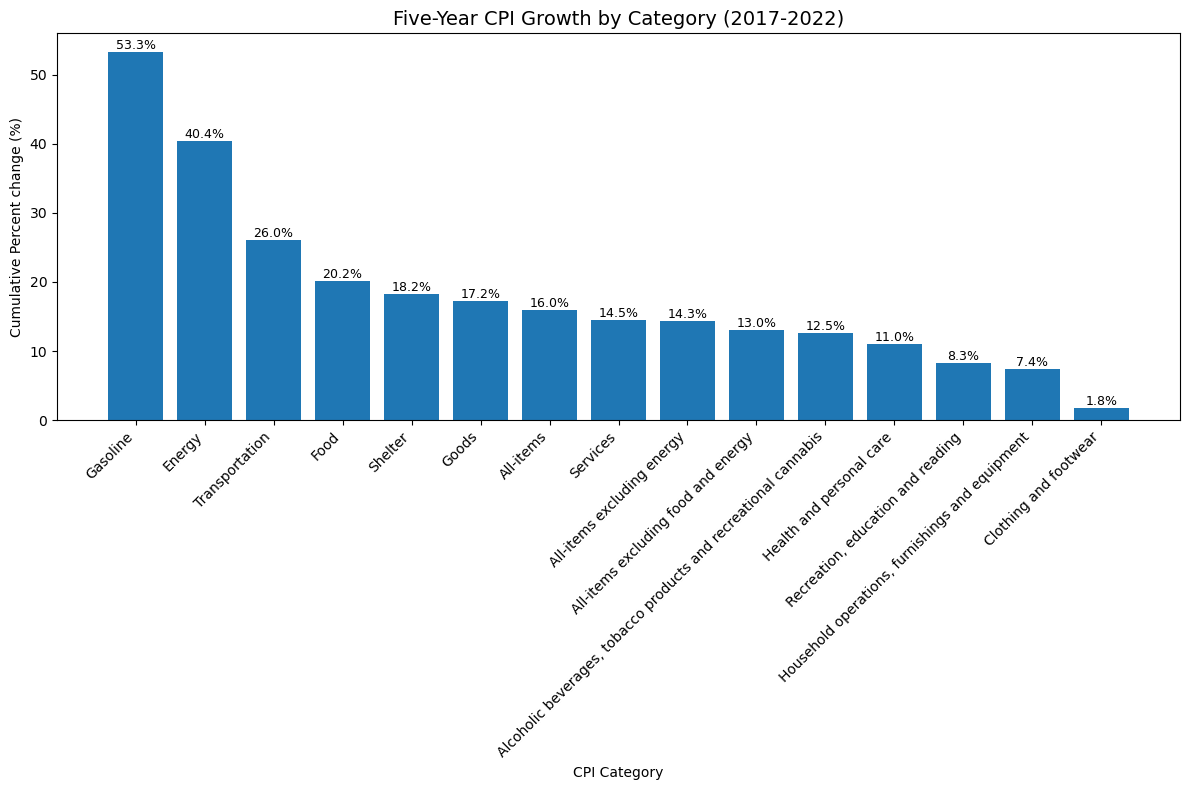

In [18]:
# Plot the Bar chart
plt.figure(figsize=(12, 8))
bars = plt.bar(growth_5y.index, growth_5y.values)

plt.title("Five-Year CPI Growth by Category (2017-2022)", fontsize=14)
plt.ylabel("Cumulative Percent change (%)")
plt.xlabel("CPI Category")
plt.xticks(rotation=45, ha='right')


for bar in bars:
  height = bar.get_height()
  plt.text(
      bar.get_x() + bar.get_width() / 2,
      height,
      f"{height:.1f}%",
      va='bottom',
      ha='center',
      fontsize=9
  )

plt.tight_layout()
plt.show()

## Which CPI category experienced the most growth over the past 5 years (2017-2022)?
The bar chart shows cummulative CPI growth across major consumption categories in Canada over the five-year period from 2017 to 2022.

Here, we observe that **Gasoline(53.3%)** and **Energy(40.4%)** experienced the highest CPI growth largely due to the global oil price volaitlity, supply disruptions and the sharp rebound in demand following the COVID-19 pandemic.

If we recall, the energy markets were affected by reduced production during lockdowns and geopolitocal tensions like the (Russia-Ukraine conflict) which pushed global energy prices higher and quickly passed on to the Canadian consumers.

**Transportation** prices increased by **26%** as fuel is considered a major input cost in Canada's transportation sector. Also, given the country's large geographic size and reliance on road transport, higher gasoline prices concurrently led to increase in commuting costs, freight costs and air travel prices.

**Food** prices rose by **20.2%** caused by higher input costs like energy, fertilizer, and transportation, along with the extreme weather events that affected agricultural production, supply-chain disruptions that affected food imports as well as pandemic-related labor shortages.

**Shelter** costs increased steadily by **18.2%** due to rising rents, growing housing demand relative to the limited housing supply and high construction & maintantance costs.

Another important aspect to note from the chart is that when energy is excluded, inflation growth is noticeably lower **((14.3%) excluding energy and (13.0%) excluding food and energy)** indicating how energy and food were major drivers of inflation in Canada during this period.

The remaining categories recorded relatively insiginifcant growth during this period compared to enery-related components.

## Key Findings

# Is the CPI growing for all basket categories?
From the chart, we observe that all the CPI basket categories experienced positive growth over the five year period. However, it is obvious that the rate of growth varies substantially across categories.

- Essentials like energy, food, and shelter increased significantly.
- While non-essential categories including clothing and recreation showed relatively small increase.

This is an indication that inflation in Canada between 2017 and 2022 were unevenly distributed with certain sectors particulay energy related components driving much of the overall CPI growth.

# Which Category has the lowest rate of growth?
Clearly, we see **Clothing and footwear** recorded the lowest rate of growth at 1.8% over the five year period. This muted growth can be attributed to the fact that clothing prices are heavily influenced by international supply chains, global competiton, and discount retailers which helps keep price increases low despite inflationary pressures in the Canadian economy.

# Which Category has the wildest and most unpredictable rate of growth?
The chart shows **Gasoline** to have the most volatile and unpredictable growth pattern with a cummulative increase of **53.3%** followed closely by Energy at 40.4%.

The singular driving factor is said to be that in Canada as in every other country, gasoline prices are higly sensitive to global oil markets, exchange rates fluctuations, geopoltical events like the (Russia-Ukarine conflict), and refinery disruptions.

In this scenario, the sharp price decline during the early stages of the COVID-19 pandemic, followed by surge during the economic recovery contirbuted to this volatility, making gasoline the most unstable CPI component over the period.

# Are Food and Shelter growing at the same pace?
Not necessarily. While both Food and Shelter` prices increased significantly between the five year period, they did not grow at the same pace.

Food prices increased by 20.2% compared to 18.2% for Shelter.

Here's why:

According to the Bank of Canada's article *[What drives up the price of groceries](https://www.bankofcanada.ca/2024/07/what-drives-up-the-price-of-groceries/)* food prices are particularly sensitive to rising energy and transportation costs, weather-related supply disruptions, and Canada's reliance on imported food. Because food production and distribution are highly energy intensive, major increases in fuel prices and fertilizer costs are often passed down to consumers in form of higher grocery prices.

In contrast, inflation in Shelter category is primarly as a result of longer-term structural factors like shortage in housing supply, high demand fueled by population growth and rising construction and maintenance costs.

This explains why, although both categories experienced strong inflation, Food prices rose faster than Shelter prices, as they were influenced by different economic forces impacting the growth pace.

## Conclusion

The analysis shows that inflation in Canada between 2017 and 2022 was not uniform across consumption categories, but was instead heavily influenced by volatility in energy markets.

- Energy and fuel prices emerged as the primary drivers of CPI growth, amplifying cost pressures across multiple sectors, including transportation and food.

- In contrast, categories such as clothing and footwear remained relatively stable, highlighting the differing sensitivity of CPI components to global economic shocks.

- Food prices grew faster than shelter costs, reflecting their higher exposure to short-term shocks such as supply chain disruptions and input cost increases.